In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import contextlib
import io
import numpy as np
from datetime import date
from scipy.optimize import minimize
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather

from aquacrop_slovenia import config
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameters_running_jablje import (
    jablje_soil_layers,
    jablje_curve_number,
    jablje_readily_evaporable_water,
    jablje_maize_params,
    jablje_optimal_management,
    jablje_initial_cond,
    jablje_groundwater
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [4]:
LOCATION = "jablje"
output_dir = config.MODEL_RUNNING_DIR / "calibration_jablje"

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024) if year not in [2017]
]

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_yield = get_yield_for_comparison(LOCATION, "grain", "A", "N3")

In [5]:
# Parameters to calibrate: param_name -> (initial_value, lower_bound, upper_bound)
# Add or remove entries here to control what gets calibrated.
calibration_params = {
    "harvest_index":        (0.51, 0.45, 0.55),
    "gdd_flowering":        (508, 450, 550),
    "gdd_flowering_length": (150, 120, 180),
    "max_canopy_cover":     (0.90, 0.85, 0.98),
    "min_rooting_depth":    (0.30, 0.1, 0.5),
    "max_rooting_depth":    (2.3, 1.1, 2.5)
}

param_names = list(calibration_params.keys())
x0     = np.array([v[0] for v in calibration_params.values()])
bounds = [(v[1], v[2]) for v in calibration_params.values()]

# Parameters whose original value is int must stay int — AquaCrop's Fortran
# reader uses integer format for these fields and crashes if floats are used.
INTEGER_PARAMS = {
    name for name, val in jablje_maize_params.items() if isinstance(val, int)
}

print("Parameters to calibrate:")
for name, (init, lo, hi) in calibration_params.items():
    print(f"  {name}: initial={init}, bounds=[{lo}, {hi}]")

Parameters to calibrate:
  harvest_index: initial=0.51, bounds=[0.45, 0.55]
  gdd_flowering: initial=508, bounds=[450, 550]
  gdd_flowering_length: initial=150, bounds=[120, 180]
  max_canopy_cover: initial=0.9, bounds=[0.85, 0.98]
  min_rooting_depth: initial=0.3, bounds=[0.1, 0.5]
  max_rooting_depth: initial=2.3, bounds=[1.1, 2.5]


In [6]:
iteration = [0]

def objective(x):
    iteration[0] += 1

    for j in range(len(x)):
        if param_names[j] in INTEGER_PARAMS:
            jablje_maize_params[param_names[j]] = int(round(x[j]))
        else:
            jablje_maize_params[param_names[j]] = x[j]

    crop = Crop(
        name=f"{LOCATION} maize",
        description=f"{LOCATION} maize (calibrating)",
        params=jablje_maize_params,
    )
    simulation = AquaCrop(
        simulation_periods=simulation_periods,
        crop=crop,
        soil=soil,
        management=jablje_optimal_management,
        initial_conditions=jablje_initial_cond,
        climate=weather,
        ground_water=jablje_groundwater,
        working_dir=output_dir,
        need_daily_output=False,
        need_seasonal_output=True,
        need_harvest_output=False,
        need_evaluation_output=False,
    )

    try:
        with contextlib.redirect_stdout(io.StringIO()):
            results = simulation.run()
    except Exception as e:
        print(f"Iter {iteration[0]:4d}: FAILED — {type(e).__name__}: {e}")
        return 1e6

    seasonal = (
        results["season"][["Year1", "Y(dry)"]]
        .rename(columns={"Year1": "year", "Y(dry)": "yield_modeled"})
    )
    merged = observed_yield.merge(seasonal, on="year")
    rmse = root_mean_squared_error(merged["yield"], merged["yield_modeled"])

    vals = ", ".join(f"{n}={v:.4f}" for n, v in zip(param_names, x))
    print(f"Iter {iteration[0]:4d}: RMSE={rmse:.4f}  [{vals}]")

    return rmse

In [7]:
iteration[0] = 0

result = minimize(
    objective,
    x0,
    method="Nelder-Mead",
    bounds=bounds,
    options={
        "maxiter": 20,
        "xatol": 1e-2,
        "fatol": 1e-4,
        "adaptive": True,
    }
)

print(f"\nOptimization {'succeeded' if result.success else 'did not fully converge'}: {result.message}")
print(f"Iterations: {iteration[0]}")
print(f"Final RMSE: {result.fun:.4f}")
print("\nCalibrated parameters:")
for name, val in zip(param_names, result.x):
    print(f"  {name}: {val:.6f}  (initial: {calibration_params[name][0]})")

Iter    1: RMSE=2.1982  [harvest_index=0.5100, gdd_flowering=508.0000, gdd_flowering_length=150.0000, max_canopy_cover=0.9000, min_rooting_depth=0.3000, max_rooting_depth=2.3000]
Iter    2: RMSE=2.4224  [harvest_index=0.5355, gdd_flowering=508.0000, gdd_flowering_length=150.0000, max_canopy_cover=0.9000, min_rooting_depth=0.3000, max_rooting_depth=2.3000]
Iter    3: RMSE=2.2380  [harvest_index=0.5100, gdd_flowering=533.4000, gdd_flowering_length=150.0000, max_canopy_cover=0.9000, min_rooting_depth=0.3000, max_rooting_depth=2.3000]
Iter    4: RMSE=2.2047  [harvest_index=0.5100, gdd_flowering=508.0000, gdd_flowering_length=157.5000, max_canopy_cover=0.9000, min_rooting_depth=0.3000, max_rooting_depth=2.3000]
Iter    5: RMSE=2.2899  [harvest_index=0.5100, gdd_flowering=508.0000, gdd_flowering_length=150.0000, max_canopy_cover=0.9450, min_rooting_depth=0.3000, max_rooting_depth=2.3000]
Iter    6: RMSE=2.1988  [harvest_index=0.5100, gdd_flowering=508.0000, gdd_flowering_length=150.0000, max

Setting up working directory at: E:\aquacrop\calibration_jablje
Running AquaCrop simulation with project file: E:\aquacrop\calibration_jablje\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: E:\aquacrop\calibration_jablje\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed
1.976970712984894
0.07176217055422629


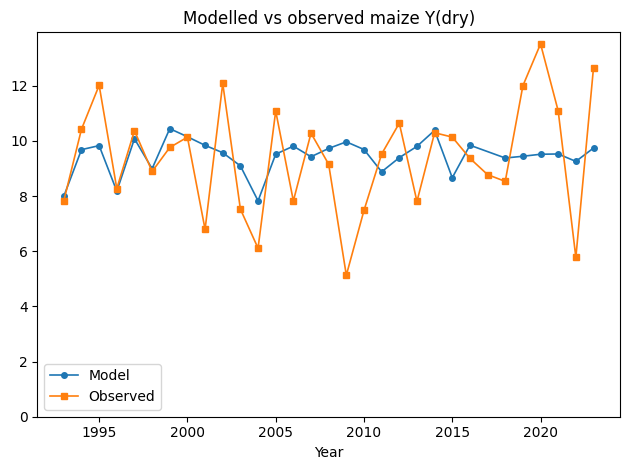

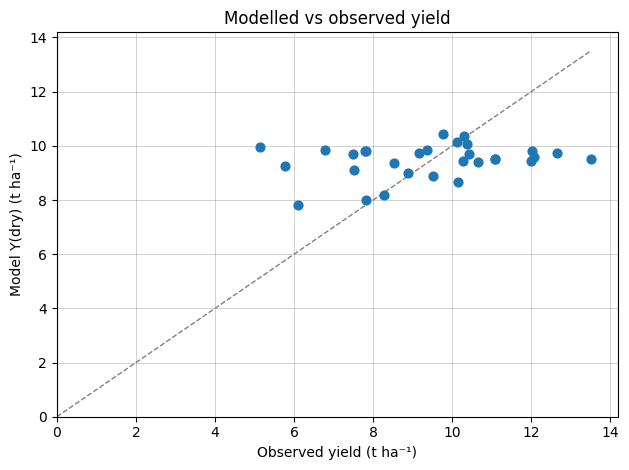

In [8]:
for j in range(len(result.x)):
        if param_names[j] in INTEGER_PARAMS:
            jablje_maize_params[param_names[j]] = int(round(result.x[j]))
        else:
            jablje_maize_params[param_names[j]] = result.x[j]

calibrated_crop = Crop(
    name=f"{LOCATION} maize calibrated",
    description=f"{LOCATION} maize calibrated",
    params=jablje_maize_params
)

final_simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=calibrated_crop,
    soil=soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=weather,
    working_dir=output_dir,
    need_daily_output=False,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False,
)

final_results = final_simulation.run()
final_seasonal = final_results["season"]

print(root_mean_squared_error(observed_yield["yield"].values, final_seasonal.loc[:, "Y(dry)"].values))
print(r2_score(observed_yield["yield"].values, final_seasonal.loc[:, "Y(dry)"].values))

plot_yield_timeseries_comparison(final_seasonal, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)", LOCATION)
plot_yield_scatter(final_seasonal, get_yield(LOCATION, "grain", "A", "N3"))